In [21]:
import requests

# Jacksonville, FL coordinates
latitude = 30.3322
longitude = -81.6557

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
    "timezone": "America/New_York",
    "start_date": "2026-05-01",
    "end_date": "2026-05-31",
    "temperature_unit": "fahrenheit",
    "precipitation_unit": "inch"
}

response = requests.get(url, params=params)
data = response.json()

print(data)

{'latitude': 30.322327, 'longitude': -81.644424, 'generationtime_ms': 0.16760826110839844, 'utc_offset_seconds': -14400, 'timezone': 'America/New_York', 'timezone_abbreviation': 'GMT-4', 'elevation': 6.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_max': '°F', 'temperature_2m_min': '°F', 'precipitation_sum': 'inch'}, 'daily': {'time': ['2026-05-01', '2026-05-02', '2026-05-03', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08', '2026-05-09', '2026-05-10', '2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-16', '2026-05-17', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-23', '2026-05-24', '2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29', '2026-05-30', '2026-05-31'], 'temperature_2m_max': [None, None, None, None, None, None, None, None, 84.3, 87.4, 92.8, 78.2, 81.1, 90.3, 83.3, 92.6, 91.0, 88.7, 90.8, 92.1, 96.6, 94.2, 89.8, 90.4, 88.7, 89.8, 91.9, 89.2, 87.3, 84.3, 84.8], 'temperatu

In [22]:
import pandas as pd

# Pull out the daily data into a table
df = pd.DataFrame({
    "date": data["daily"]["time"],
    "high_temp_F": data["daily"]["temperature_2m_max"],
    "low_temp_F": data["daily"]["temperature_2m_min"],
    "rain_inches": data["daily"]["precipitation_sum"]
})

df

,date,high_temp_F,low_temp_F,rain_inches
0,2026-05-01,NaN,NaN,NaN
1,2026-05-02,NaN,NaN,NaN
2,2026-05-03,NaN,NaN,NaN
3,2026-05-04,NaN,NaN,NaN
4,2026-05-05,NaN,NaN,NaN
5,2026-05-06,NaN,NaN,NaN
6,2026-05-07,NaN,NaN,NaN
7,2026-05-08,NaN,NaN,NaN
8,2026-05-09,84.3,73.7,NaN
9,2026-05-10,87.4,70.1,0.382


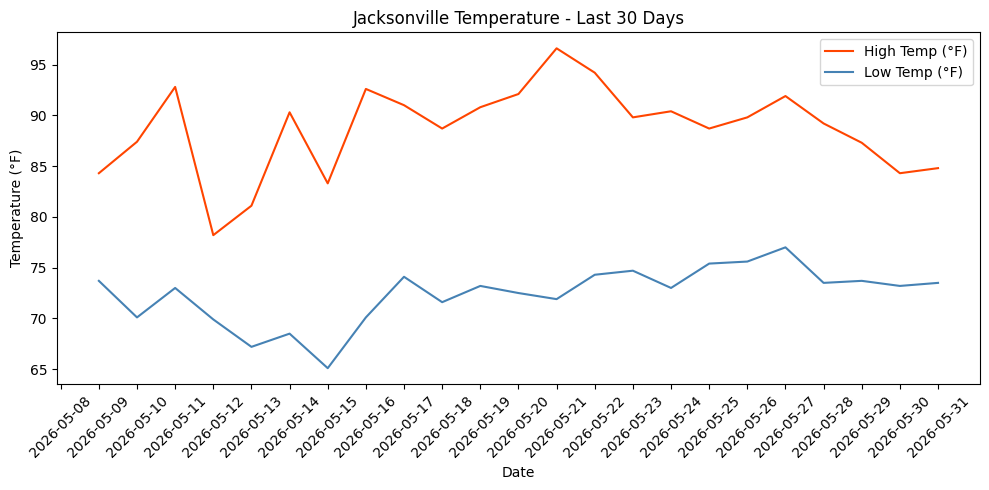

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["high_temp_F"], label="High Temp (°F)", color="orangered")
plt.plot(df["date"], df["low_temp_F"], label="Low Temp (°F)", color="steelblue")

plt.title("Jacksonville Temperature - Last 30 Days")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

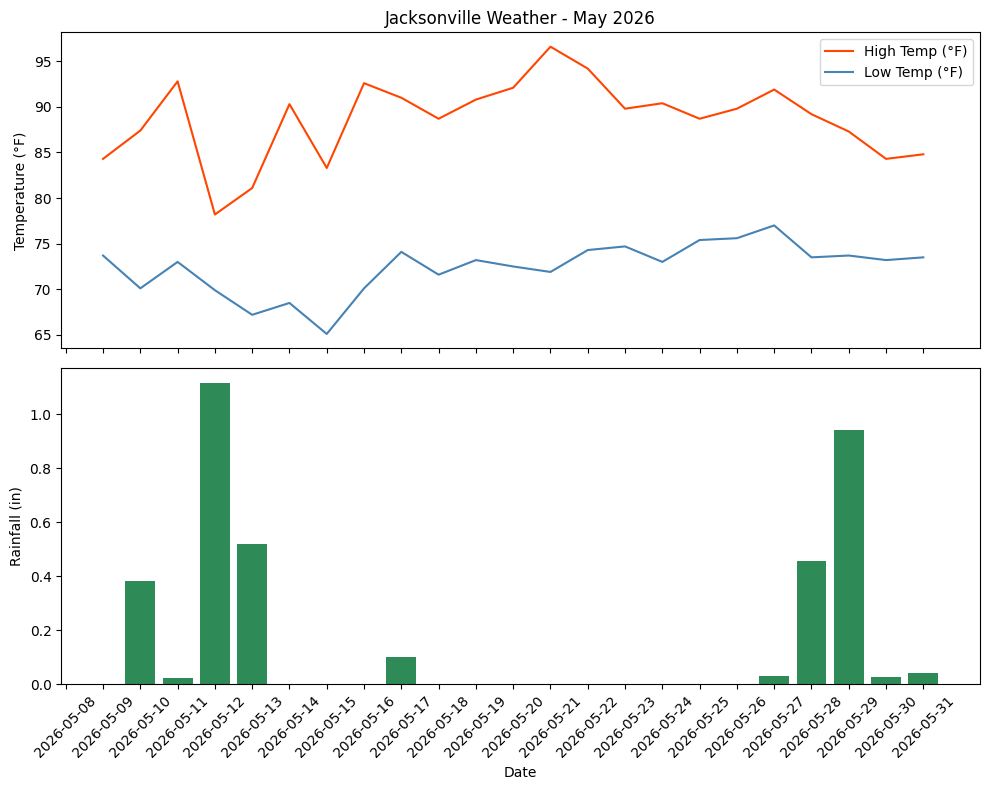

In [24]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top chart: temperatures
ax1.plot(df["date"], df["high_temp_F"], label="High Temp (°F)", color="orangered")
ax1.plot(df["date"], df["low_temp_F"], label="Low Temp (°F)", color="steelblue")
ax1.set_ylabel("Temperature (°F)")
ax1.set_title("Jacksonville Weather - May 2026")
ax1.legend()

# Bottom chart: precipitation
ax2.bar(df["date"], df["rain_inches"], color="seagreen")
ax2.set_ylabel("Rainfall (in)")
ax2.set_xlabel("Date")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()